### loading the libraries

In [25]:
%load_ext autoreload
%autoreload 2

In [1]:
import os
import sys
import time

import pandas as pd
import numpy as np
from dotenv import load_dotenv
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
import matplotlib.pyplot as plt


In [5]:
#from openai import OpenAI
# Gemini instead of OpenAI
import google.genai as genai
from google.genai import types


In [2]:
from groq import Groq

In [3]:
# Load API key from .env file
load_dotenv("../.env")
#OpenAI.api_key = os.getenv("OPENAI_API_KEY")
 #Create client
#client = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))
client = Groq(api_key=os.getenv("GROK_API_KEY"))

# Add src to path
sys.path.append(os.path.abspath("../src"))

from prompts import PROMPT_SIMPLE, PROMPT_DETAILED, PROMPT_FEWSHOT, PROMPT_MORE_DETAILED

#print("Setup complete. Using Gemini.")
print("Setup complete. Using Groq.")

Setup complete. Using Groq.


### Load the data

In [4]:
df = pd.read_csv("../data/train.csv")

print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst comment:\n{df['comment_text'].iloc[0][:200]}...")

Shape: (159571, 8)

Columns: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

First comment:
Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove th...


In [ ]:
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [5]:
# Check label distribution
print("\n--- Label Distribution ---")
for col in ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']:
    count = df[col].sum()
    pct = df[col].mean() * 100
    print(f"{col:15s}: {count:6d} ({pct:5.2f}%)")



--- Label Distribution ---
toxic          :  15294 ( 9.58%)
severe_toxic   :   1595 ( 1.00%)
obscene        :   8449 ( 5.29%)
threat         :    478 ( 0.30%)
insult         :   7877 ( 4.94%)
identity_hate  :   1405 ( 0.88%)


### Sampling the data - taking 500 sample from TOXIC label 
Hence we get a balanced dataset



In [6]:
# Create a balanced 500-sample dataset
SAMPLE_SIZE = 100
SEED = 42

toxic = df[df["toxic"] == 1].sample(n=SAMPLE_SIZE // 2, random_state=SEED)
safe = df[df["toxic"] == 0].sample(n=SAMPLE_SIZE // 2, random_state=SEED)

sample_all = pd.concat([toxic, safe])
sample_all = sample_all.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"Sample shape: {sample_all.shape}")
print(f"Toxic: {sample_all['toxic'].sum()}")
print(f"Safe:  {(sample_all['toxic'] == 0).sum()}")

Sample shape: (100, 8)
Toxic: 50
Safe:  50


In [7]:
sample = sample_all[["comment_text", "toxic"]].copy()
sample.head()

,comment_text,toxic
0,"I'm so glad I have your approval. 07:25, 24 F...",0
1,"""\nYes, my cat was subject to attempt to test ...",0
2,"""\n\n Some baklava for you! \n\n I'm sorry. I...",0
3,"That's no personal attack, that's the truth. H...",1
4,"Of course, you dummy. Look at the politics of ...",1


In [9]:
# Extract lists for easy use
comments = sample["comment_text"].tolist()
labels = sample["toxic"].tolist()

# Baseline classifier

In [10]:
# Simple keyword-based classifier for comparison
BAD_WORDS = [
    'hate', 'stupid', 'idiot', 'kill', 'die', 'ugly', 'moron', 'dumb',
    'retard', 'fuck', 'shit', 'bitch', 'asshole', 'damn', 'loser',
    'trash', 'worthless', 'pathetic'
]

def keyword_predict(texts):
    preds = []
    for text in texts:
        text_lower = text.lower()
        pred = 1 if any(w in text_lower for w in BAD_WORDS) else 0
        preds.append(pred)
    return preds

baseline_preds = keyword_predict(comments)

print("=== KEYWORD BASELINE ===")
print(classification_report(labels, baseline_preds, digits=3))
print("Confusion Matrix:")
print(confusion_matrix(labels, baseline_preds))

=== KEYWORD BASELINE ===
              precision    recall  f1-score   support

           0      0.638     0.880     0.739        50
           1      0.806     0.500     0.617        50

    accuracy                          0.690       100
   macro avg      0.722     0.690     0.678       100
weighted avg      0.722     0.690     0.678       100

Confusion Matrix:
[[44  6]
 [25 25]]


In [ ]:
for model in client.models.list():
    print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gemini-2.5-computer-use-preview-10-2025
models/deep-research-max-preview-04-2026
models/deep-research-prev

In [11]:
test_comment = "You are a complete idiot and I hope you die"
"""
response = client.models.generate_content(
    model="gemini-3.1-flash-lite", # Picked from available models
    contents=PROMPT_SIMPLE.format(comment=test_comment)
)"""

# Quick test
response = client.chat.completions.create(
    model="llama-3.1-8b-instant",
    messages=[{"role": "user", "content": PROMPT_FEWSHOT.format(comment=test_comment)}],
    max_tokens=5,
    temperature=0
)

#answer = response.text.strip().lower()
print(response.choices[0].message.content)
#print(f"Comment: {test_comment[:80]}...")
#print(f"LLM says: {answer}")
#print(f"Parsed: {'TOXIC' if 'yes' in answer else 'SAFE'}")

yes


In [12]:
def llm_classify_batch(comments, prompt_template, delay=0.5):
    predictions = []
    total = len(comments)
    
    for i, comment in enumerate(comments, 1):
        try:
            response = client.models.generate_content(
                model="gemini-3.1-flash-lite",  # or "gemini-3.1-flash-lite" if that's what works
                contents=prompt_template.format(comment=comment)
            )
            answer = response.text.strip().lower()
            pred = 1 if "yes" in answer else 0
            
        except Exception as e:
            print(f"Error on comment {i}: {e}")
            pred = 0
        
        predictions.append(pred)
        time.sleep(delay)
        
        if i % 50 == 0:
            print(f"  Progress: {i}/{total}")
    
    return predictions

In [14]:
def llm_classify_batch_grok(comments, prompt_template, delay=0.5):
    predictions = []
    total = len(comments)
    
    for i, comment in enumerate(comments, 1):
        try:
            response = client.chat.completions.create(
                model="llama-3.1-8b-instant",
                messages=[{"role": "user", "content": prompt_template.format(comment=comment)}],
                max_tokens=5,
                temperature=0
            )
            answer = response.choices[0].message.content.strip().lower()
            pred = 1 if "yes" in answer else 0
            
        except Exception as e:
            print(f"Error on comment {i}: {e}")
            pred = 0
        
        predictions.append(pred)
        time.sleep(delay)
        
        if i % 50 == 0:
            print(f"  Progress: {i}/{total}")
    
    return predictions

## Google genai results

In [ ]:
print(">>> Running Prompt A: Simple")
pred_a = llm_classify_batch(comments, PROMPT_SIMPLE)
sample["pred_simple"] = pred_a

print("\n=== Prompt A Results ===")
print(classification_report(labels, pred_a, digits=3))

>>> Running Prompt A: Simple
  Progress: 50/100
  Progress: 100/100

=== Prompt A Results ===
              precision    recall  f1-score   support

           0      0.776     0.900     0.833        50
           1      0.881     0.740     0.804        50

    accuracy                          0.820       100
   macro avg      0.828     0.820     0.819       100
weighted avg      0.828     0.820     0.819       100



In [ ]:
print(">>> Running Prompt B: Detailed Definition")
pred_b = llm_classify_batch(comments, PROMPT_DETAILED)
sample["pred_detailed"] = pred_b

print("\n=== Prompt B Results ===")
print(classification_report(labels, pred_b, digits=3))

>>> Running Prompt B: Detailed Definition
  Progress: 50/100
  Progress: 100/100

=== Prompt B Results ===
              precision    recall  f1-score   support

           0      0.846     0.880     0.863        50
           1      0.875     0.840     0.857        50

    accuracy                          0.860       100
   macro avg      0.861     0.860     0.860       100
weighted avg      0.861     0.860     0.860       100



In [ ]:
print(">>> Running Prompt C: Few-Shot")
pred_c = llm_classify_batch(comments, PROMPT_FEWSHOT)
sample["pred_fewshot"] = pred_c

print("\n=== Prompt C Results ===")
print(classification_report(labels, pred_c, digits=3))

>>> Running Prompt C: Few-Shot
Error on comment 46: 'NoneType' object has no attribute 'strip'
  Progress: 50/100
  Progress: 100/100

=== Prompt C Results ===
              precision    recall  f1-score   support

           0      0.870     0.800     0.833        50
           1      0.815     0.880     0.846        50

    accuracy                          0.840       100
   macro avg      0.842     0.840     0.840       100
weighted avg      0.842     0.840     0.840       100



## GROK results


In [17]:
print(">>> Running Prompt A: Simple")
pred_a = llm_classify_batch_grok(comments, PROMPT_SIMPLE)
sample["pred_simple"] = pred_a

print("\n=== Prompt A Results ===")
print(classification_report(labels, pred_a, digits=3))

>>> Running Prompt A: Simple
  Progress: 50/100
  Progress: 100/100

=== Prompt A Results ===
              precision    recall  f1-score   support

           0      0.833     0.900     0.865        50
           1      0.891     0.820     0.854        50

    accuracy                          0.860       100
   macro avg      0.862     0.860     0.860       100
weighted avg      0.862     0.860     0.860       100



In [15]:
print(">>> Running Prompt C: Few-Shot")
pred_c = llm_classify_batch_grok(comments, PROMPT_FEWSHOT)
sample["pred_fewshot"] = pred_c

print("\n=== Prompt C Results ===")
print(classification_report(labels, pred_c, digits=3))

>>> Running Prompt C: Few-Shot
  Progress: 50/100
  Progress: 100/100

=== Prompt C Results ===
              precision    recall  f1-score   support

           0      0.951     0.780     0.857        50
           1      0.814     0.960     0.881        50

    accuracy                          0.870       100
   macro avg      0.882     0.870     0.869       100
weighted avg      0.882     0.870     0.869       100



In [29]:
print(PROMPT_MORE_DETAILED.format(comment=comments[-1]))

You are a content moderator for a large platform. 
A comment is toxic if it:
- Attacks someone personally (insults, name-calling, mockery)
- Contains hate speech or discrimination against a group
- Includes threats or wishes harm on a person or group
- Uses severe profanity in an attacking or demeaning way
- Uses sarcasm or irony to belittle or demean someone
- Dismisses or demeans someone's intelligence or worth ("you clearly don't understand anything")
- Makes someone feel unwelcome or excluded based on who they are
- Uses backhanded compliments or passive-aggressive language to attack


Does this comment meet the toxic criteria? Reply only "yes" or "no".

Comment: Well, if The Tartan, a sometime student publication of CMU that was disbanded for a year after publishing racist cartoons and spoofs is the source of your information, not the two major dailies in town, then you're on to something!  Brilliant expose, editors!

Answer:


In [28]:
import importlib
import prompts
importlib.reload(prompts)
from prompts import PROMPT_SIMPLE, PROMPT_DETAILED, PROMPT_FEWSHOT, PROMPT_MORE_DETAILED

In [ ]:
print(">>> Running Prompt D: MORE DETAILED")
pred_d = llm_classify_batch_grok(comments, PROMPT_MORE_DETAILED)
sample["pred_moredetailed"] = pred_d

print("\n=== Prompt D2 Results ===")
print(classification_report(labels, pred_d, digits=3))

>>> Running Prompt D: MORE DETAILED
  Progress: 50/100
  Progress: 100/100

=== Prompt D2 Results ===
              precision    recall  f1-score   support

           0      0.849     0.900     0.874        50
           1      0.894     0.840     0.866        50

    accuracy                          0.870       100
   macro avg      0.871     0.870     0.870       100
weighted avg      0.871     0.870     0.870       100



In [21]:
results = []

def add_result(name, preds):
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(labels, preds),
        "Precision": precision_score(labels, preds, zero_division=0),
        "Recall": recall_score(labels, preds, zero_division=0),
        "F1": f1_score(labels, preds, zero_division=0),
    })

# Add your baseline + all prompt results
add_result("Keyword_Baseline", baseline_preds)
add_result("LLM_Simple", pred_a)
add_result("LLM_MOREDetailed", pred_d)
add_result("LLM_FewShot", pred_c)

results_df = pd.DataFrame(results).round(3)
print(results_df.to_string(index=False))

# Save
results_df.to_csv("../outputs/comparison_metrics.csv", index=False)

           Model  Accuracy  Precision  Recall    F1
Keyword_Baseline      0.69      0.806    0.50 0.617
      LLM_Simple      0.86      0.891    0.82 0.854
LLM_MOREDetailed      0.88      0.880    0.88 0.880
     LLM_FewShot      0.87      0.814    0.96 0.881


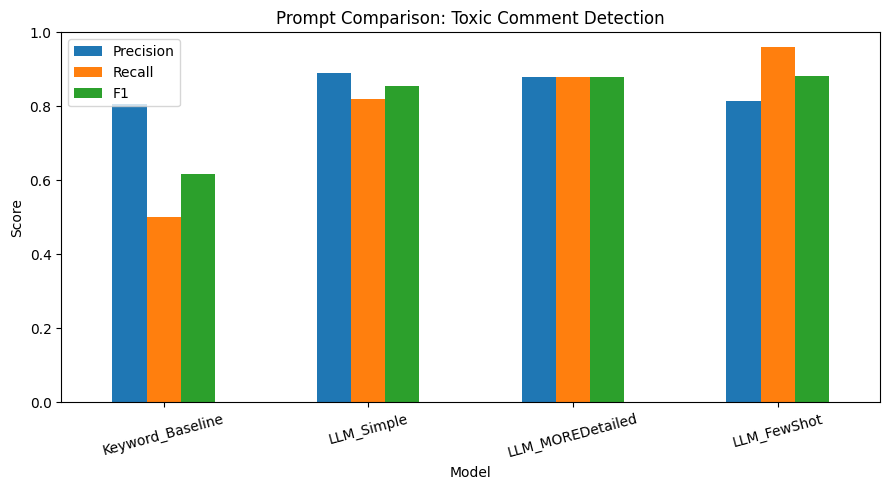

In [22]:
results_df.plot(x="Model", y=["Precision", "Recall", "F1"], kind="bar", figsize=(9, 5))
plt.title("Prompt Comparison: Toxic Comment Detection")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../outputs/comparison_chart.png")
plt.show()

In [31]:
results_df.to_csv("../outputs/comparison_metrics.csv", index=False)
print("Saved to outputs/comparison_metrics.csv")

Saved to outputs/comparison_metrics.csv


In [32]:
best_col = "pred_fewshot"

# False negatives (missed toxicity)
fn = sample[(sample["toxic"] == 1) & (sample[best_col] == 0)]
print(f"False Negatives: {len(fn)}")
for _, row in fn.head(5).iterrows():
    print(f"  - {row['comment_text'][:120]}...")

# False positives (over-flagged)
fp = sample[(sample["toxic"] == 0) & (sample[best_col] == 1)]
print(f"\nFalse Positives: {len(fp)}")
for _, row in fp.head(5).iterrows():
    print(f"  - {row['comment_text'][:120]}...")

False Negatives: 2
  - J Bar and C Fred are having anal sex together....
  - You're watching Dirty Jobs too I guess? Haha......

False Positives: 11
  - I'm so glad I have your approval.  07:25, 24 Feb 2004 (UTC)...
  - It's a game? 
I must be retarded because I played this game and all I have to say is don't ever come wihin 50 feet of it...
  - "== TfD nomination of Template:SilentRedirect ==

Template:SilentRedirect has been nominated for deletion. You are invit...
  - Who are You? Where is you name and Address ? 

Utkarshraj Atmaram is a friendly Wikipedia administrator from India, who ...
  - Trigor's edit

 have erases pointing out that nuclear waste is stored in unprotected place and that is venerable to terr...
